Step 1: Import Libaries 

I have imported required libraries for data analysis and preprocessing.

In [133]:
import pandas as pd
import numpy as np

Step 2: Load Dataset 

The dataset is loaded using pandas to begin analysis.

In [134]:
df = pd.read_csv("bengaluru_house_prices.csv")
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


Step 3: Initial Data Analysis

I analyze the dataset structure including rows, columns, and data types.

In [135]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


Missing Values Check 

Dataset contains 13320 rows and 9 columns. Some columns contains missing values which require cleaning.

In [136]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Step 4: Remove Irrelevant Columns

Columns like 'area_type', 'availability', and 'society' are removed as they are not useful for prediction or contain too many missing values. 

In [137]:
df = df.drop(["area_type", "availability", "society"], axis=1)

In [138]:
df.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


Step 5: Convert Size to BHK

The 'size' column contains values like '2BHK'. We extract numeric values to create a new column 'bhk'.

In [139]:
df["bhk"] = df["size"].str.extract(r'(\d+)').astype(float)
df = df.drop("size", axis=1)

In [140]:
df["bhk"].head()

0    2.0
1    4.0
2    3.0
3    3.0
4    2.0
Name: bhk, dtype: float64

Step 6: Clean total_sqft Column

The 'total_sqft' column contains inconsistent formats such as ranges (e.g., '2100 - 2850'). 
These are converted into numeric values 

In [141]:
df["total_sqft"].unique()

<StringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
 ...
        '3124',        '9200',         '613',         '250',        '2395',
 '1020 - 1130',        '2758', '1133 - 1384',         '774',        '4689']
Length: 2117, dtype: str

In [142]:
def convert_sqft(x):
    try:
        if '-' in str(x):
            a, b = x.split('-')
            return (float(a) + float(b)) / 2
        return float(x)
    except:
        return None
    

df["total_sqft"] = df["total_sqft"].apply(convert_sqft)
    

In [143]:
df["total_sqft"].info()

<class 'pandas.Series'>
RangeIndex: 13320 entries, 0 to 13319
Series name: total_sqft
Non-Null Count  Dtype  
--------------  -----  
13274 non-null  float64
dtypes: float64(1)
memory usage: 104.2 KB


Step 7: Handle Missing Values 

Rows with missing values are removed to ensure clean data for machine learning.

In [144]:
df.isnull().sum()

location        1
total_sqft     46
bath           73
balcony       609
price           0
bhk            16
dtype: int64

In [145]:
df = df.dropna()

In [146]:
df.isnull().sum()

location      0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
dtype: int64

Step 8: Outlier Removal

We remove unrealistic data points such as:
- Houses with very low area per bedroom
- Extremely High Prices

In [147]:
df.head()

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [148]:
df["total_sqft"] / df["bhk"]         #gives sqft per room 

0         528.000000
1         650.000000
2         480.000000
3         507.000000
4         600.000000
            ...     
13314     571.666667
13315     690.600000
13317     570.500000
13318    1172.250000
13319     550.000000
Length: 12668, dtype: float64

In [149]:
# Remove unrealistic sqft per bhk
df = df[df["total_sqft"] / df["bhk"] > 300]

In [150]:
df.describe()

,total_sqft,bath,balcony,price,bhk
count,11847.000000,11847.000000,11847.000000,11847.000000,11847.000000
mean,1547.973487,2.495568,1.590107,104.513195,2.590614
std,1187.743004,0.991927,0.807568,134.782627,0.909573
min,340.000000,1.000000,0.000000,9.000000,1.000000
25%,1105.000000,2.000000,1.000000,48.000000,2.000000
50%,1295.000000,2.000000,2.000000,68.000000,2.000000
75%,1665.000000,3.000000,2.000000,110.000000,3.000000
max,52272.000000,13.000000,3.000000,2912.000000,13.000000


In [ ]:
#Remove extreme price value (Remove houses priced above 3Cr aprox)
df = df[df["price"] < 300]

Step 9: Final Dataset Check 

I verify that the dataset is clean, numeric, and ready for machine learning except Location column

In [152]:
df.info()

<class 'pandas.DataFrame'>
Index: 11227 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    11227 non-null  str    
 1   total_sqft  11227 non-null  float64
 2   bath        11227 non-null  float64
 3   balcony     11227 non-null  float64
 4   price       11227 non-null  float64
 5   bhk         11227 non-null  float64
dtypes: float64(5), str(1)
memory usage: 614.0 KB


In [153]:
df.describe()

,total_sqft,bath,balcony,price,bhk
count,11227.000000,11227.000000,11227.000000,11227.000000,11227.000000
mean,1429.721579,2.400998,1.575488,81.573023,2.512158
std,951.312677,0.885816,0.797777,51.420385,0.832438
min,340.000000,1.000000,0.000000,9.000000,1.000000
25%,1100.000000,2.000000,1.000000,47.000000,2.000000
50%,1260.000000,2.000000,2.000000,65.000000,2.000000
75%,1600.000000,3.000000,2.000000,98.000000,3.000000
max,52272.000000,13.000000,3.000000,299.000000,13.000000


Data Visualization 

I plot a graph to observe the relationship between area and price.

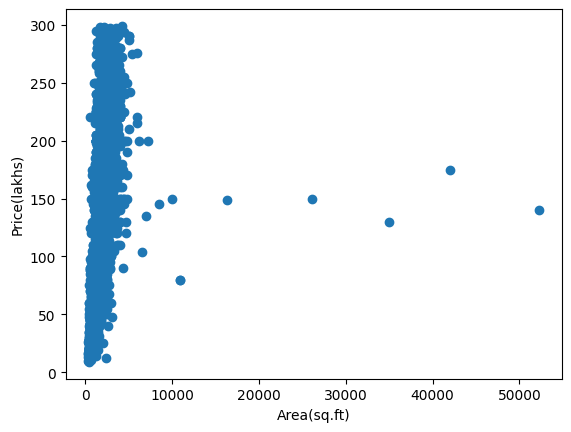

In [154]:
import matplotlib.pyplot as plt

plt.scatter(df["total_sqft"], df["price"])
plt.xlabel("Area(sq.ft)")
plt.ylabel("Price(lakhs)")
plt.show()

Location Cleaning

Setp 1: Remove space(Clean location text) 

Remove extra spaces and standardize values


In [155]:
df["location"] = df["location"].apply(lambda x:x.strip())

In [156]:
# check Unique Locations
df["location"].value_counts()

location
Whitefield                                         470
Sarjapur  Road                                     351
Electronic City                                    292
Kanakpura Road                                     257
Thanisandra                                        231
                                                  ... 
Kanakapura main  Road                                1
Kanakapur main road                                  1
Sarvobhogam Nagar                                    1
12th cross srinivas nagar banshankari 3rd stage      1
Abshot Layout                                        1
Name: count, Length: 1096, dtype: int64

Step: Reduce rare locations

Group locations with very few data points into "other"

In [157]:
location_stats = df["location"].value_counts()

df["location"] = df["location"].apply(lambda x: x if location_stats[x] > 10 else "other")  # if location apperars < 10 times then group it into "other"

Step: Convert Text to Numbers
I used one-hot encoding to Convert categorical location into numberical format, and applied drop_first = True to remove redundant columns and imporve model efficiency. 

what happens is "Whitefield" becomes location_Whitefield = 1 or 0

In [158]:
df = pd.get_dummies(df, columns=["location"], drop_first=True)

Step: final check 

In [159]:
df.head()

,total_sqft,bath,balcony,price,bhk,location_2nd Phase Judicial Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,...,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,1056.0,2.0,1.0,39.07,2.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,3.0,120.00,4.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3.0,62.00,3.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,95.00,3.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,1.0,51.00,2.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [160]:
df.info()

<class 'pandas.DataFrame'>
Index: 11227 entries, 0 to 13319
Columns: 212 entries, total_sqft to location_other
dtypes: bool(207), float64(5)
memory usage: 2.7 MB


In [161]:
df.isnull().sum()

total_sqft                     0
bath                           0
balcony                        0
price                          0
bhk                            0
                              ..
location_Yelahanka             0
location_Yelahanka New Town    0
location_Yelenahalli           0
location_Yeshwanthpur          0
location_other                 0
Length: 212, dtype: int64

Save Clean Dataset 

The cleaned dataset is saved for further use in ML training

In [163]:
df.to_csv("Cleaned_dataWithLocation.csv", index=False)

Summary:

The dataset was preprocessed by removing irrelevant columns, handling missing values, converting textual data into numeric format, and eliminating outliers.
This resulted in a clean and structured dataset suitable for machine learning model training. 

